In [1]:
import json
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches

dataset_path = '../FigureQA_Dataset/sample_train1'
annotations_file = os.path.join(dataset_path, 'annotations.json')
qa_file = os.path.join(dataset_path, 'qa_pairs.json')
images_dir = os.path.join(dataset_path, 'png')

## Preproccesing

Graph Type Counts:
type
vbar_categorical    200
hbar_categorical    200
line                200
pie                 200
dot_line            200
Name: count, dtype: int64


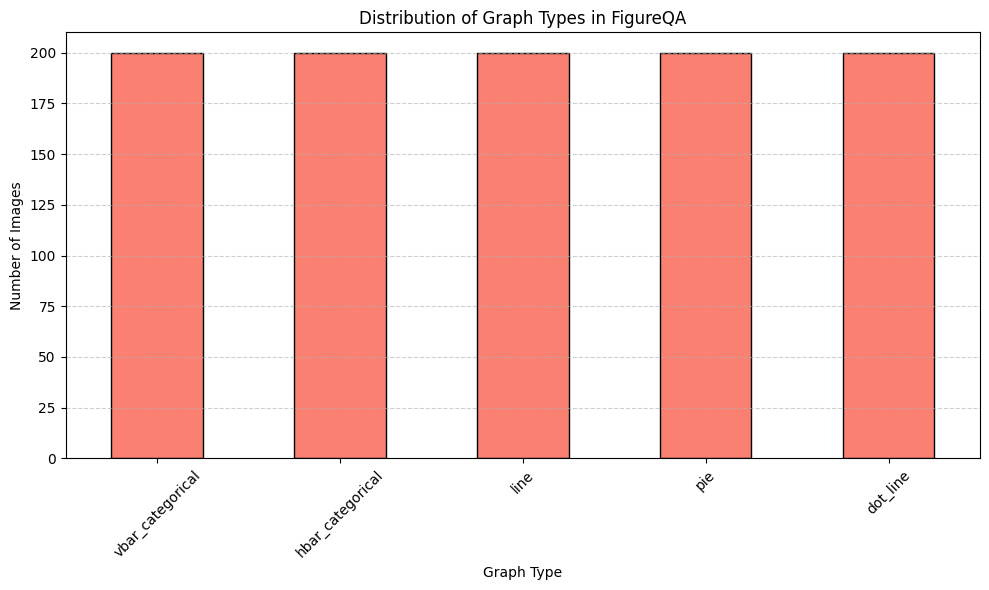

In [2]:
import pandas as pd

def get_graph_counts(file_path):
    # 1. Load the annotations
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # 2. Extract types (vbar_categorical, line, pie, etc.)
    graph_types = [item['type'] for item in data]
    
    # 3. Create a summary table
    df = pd.DataFrame(graph_types, columns=['type'])
    counts = df['type'].value_counts()
    
    print("Graph Type Counts:")
    print(counts)
    
    # 4. Visualize the distribution
    plt.figure(figsize=(10, 6))
    counts.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title("Distribution of Graph Types in FigureQA")
    plt.ylabel("Number of Images")
    plt.xlabel("Graph Type")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot for your records
    plt.savefig('dataset_distribution.png')
    plt.show()

# Run the analysis
get_graph_counts(annotations_file)

## Classify graph

In [3]:
output_dir = './classifier_sample_data'

def prepare_folders():
    with open(annotations_file, 'r') as f:
        annotations = json.load(f)

    for item in annotations:
        img_idx = item['image_index']
        graph_type = item['type']
        
        # Create folder for each type if it doesn't exist
        type_dir = os.path.join(output_dir, graph_type)
        os.makedirs(type_dir, exist_ok=True)
        
        # Copy image to its respective type folder
        src = os.path.join(images_dir, f"{img_idx}.png")
        dst = os.path.join(type_dir, f"{img_idx}.png")
        if os.path.exists(src):
            shutil.copy(src, dst)

    print(f"Data organized into {output_dir}")

prepare_folders()

Data organized into ./classifier_sample_data


In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms

# 1. Define Image Transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load organized data
dataset = datasets.ImageFolder(output_dir, transform=data_transforms)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# 3. Initialize Pre-trained ResNet18
model = models.resnet18(pretrained=True)

# Freeze early layers so we only train the new head
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) # 5 = your number of graph types

print("Model ready for training.")

Model ready for training.


/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [6]:
import torch.optim as optim
import time

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 5 

print(f"Training started on {device}...")

for epoch in range(num_epochs):
    start_time = time.time()
    
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.float() / train_size

    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    
    val_acc = val_corrects.float() / val_size
    
    duration = time.time() - start_time
    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | '
          f'Val Acc: {val_acc:.4f} | Time: {duration:.0f}s')

torch.save(model.state_dict(), 'graph_classifier.pth')
print("\nFixed! Model saved as 'graph_classifier.pth'")

Training started on mps...
Epoch 1/5 | Train Loss: 0.9718 Acc: 0.7375 | Val Acc: 0.9700 | Time: 4s
Epoch 2/5 | Train Loss: 0.2545 Acc: 0.9962 | Val Acc: 0.9850 | Time: 3s
Epoch 3/5 | Train Loss: 0.1383 Acc: 0.9987 | Val Acc: 0.9950 | Time: 5s
Epoch 4/5 | Train Loss: 0.0835 Acc: 0.9975 | Val Acc: 1.0000 | Time: 4s
Epoch 5/5 | Train Loss: 0.0618 Acc: 0.9987 | Val Acc: 0.9950 | Time: 4s

Fixed! Model saved as 'graph_classifier.pth'


Class Mapping: ['dot_line', 'hbar_categorical', 'line', 'pie', 'vbar_categorical']


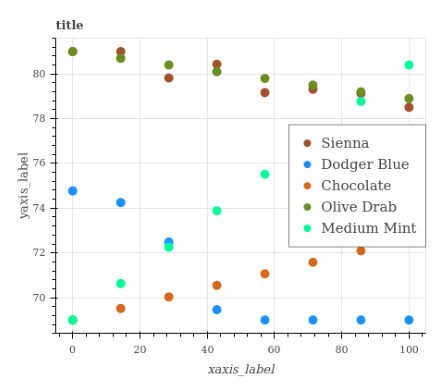


--- Vision System Output ---
Detected Graph Type: dot_line


In [7]:
import torch
from PIL import Image
import random

# 1. Setup Class Mapping
# ImageFolder assigns indices alphabetically based on folder names
class_names = dataset.classes 
print(f"Class Mapping: {class_names}")

def predict_and_summarize(image_path):
    # --- Part A: Classification ---
    model.eval()
    img = Image.open(image_path).convert('RGB')
    
    # Preprocess the image exactly like training
    img_tensor = data_transforms(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_type = class_names[preds[0]]

    print(f"\n--- Vision System Output ---")
    print(f"Detected Graph Type: {predicted_type}")


# 2. Test it on a random image from your original folder
random_idx = random.randint(0, 999)
test_image_path = os.path.join(images_dir, f"{random_idx}.png")

# Show the image
plt.imshow(Image.open(test_image_path))
plt.axis('off')
plt.show()

# Run the switch
predict_and_summarize(test_image_path)

## Extracting data from vbar_categorical

Training Model on Ground Truth Values...
Epoch 1 - MSE Loss: 0.0811
Epoch 2 - MSE Loss: 0.0332
Epoch 3 - MSE Loss: 0.0263
Epoch 4 - MSE Loss: 0.0220
Epoch 5 - MSE Loss: 0.0172
Epoch 6 - MSE Loss: 0.0100
Epoch 7 - MSE Loss: 0.0094
Epoch 8 - MSE Loss: 0.0071
Epoch 9 - MSE Loss: 0.0060
Epoch 10 - MSE Loss: 0.0064
Epoch 11 - MSE Loss: 0.0045
Epoch 12 - MSE Loss: 0.0041
Epoch 13 - MSE Loss: 0.0037
Epoch 14 - MSE Loss: 0.0043
Epoch 15 - MSE Loss: 0.0049
Model saved successfully!


/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


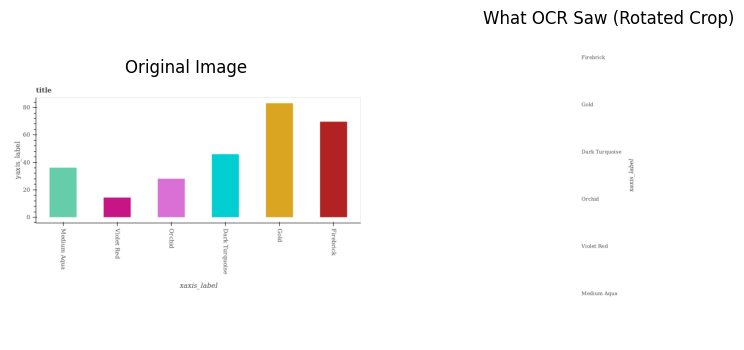

{
    "title": "title",
    "x_axis_labels": [
        "Medium Aqua",
        "Violet Red",
        "Orchid",
        "Dark Turquoise",
        "Gold",
        "Firebrick",
        "Unknown_Label_7"
    ],
    "values": [
        36.51,
        12.54,
        25.63,
        38.34,
        76.49,
        73.64,
        2.37
    ]
}


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import json
import os
import cv2
import easyocr
import numpy as np

# --- 1. CONFIGURATION ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
reader = easyocr.Reader(['en']) 
vbar_dir = './classifier_sample_data/vbar_categorical'
annotations_file = '../FigureQA_Dataset/sample_train1/annotations.json'

# --- 2. DATASET (Uses Real Annotations for Training) ---
class VBarValueDataset(Dataset):
    def __init__(self, image_dir, annotations_file, indices, transform=None):
        self.image_dir = image_dir
        with open(annotations_file, 'r') as f:
            full_data = json.load(f)
        # Filter for training images
        self.data = [item for item in full_data if item['image_index'] in indices]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.image_dir, f"{item['image_index']}.png")
        image = Image.open(img_path).convert('RGB')
        
        # GROUND TRUTH: We take the REAL values from the JSON
        values = item['models'][0]['y']
        
        # Prepare target vector (fixed size of 10 for the model)
        target = torch.zeros(10) 
        val_len = min(len(values), 10)
        # Normalize 0-100 scale down to 0-1 for the model
        target[:val_len] = torch.tensor(values[:val_len]) / 100.0 
        
        if self.transform:
            image = self.transform(image)
            
        return image, target

# --- 3. MODEL (With Sigmoid to prevent negative numbers) ---
class VBarRegressor(nn.Module):
    def __init__(self):
        super(VBarRegressor, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 10)
        self.sigmoid = nn.Sigmoid() # Forces output between 0 and 1

    def forward(self, x):
        x = self.backbone(x)
        return self.sigmoid(x)

# --- 4. TRAINING SETUP ---
# Re-load indices from previous step
image_files = [f for f in os.listdir(vbar_dir) if f.endswith('.png')]
indices = [int(f.split('.')[0]) for f in image_files]
train_idx = indices[:int(len(indices)*0.8)] # Simple split

# Setup Data
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_dataset = VBarValueDataset(vbar_dir, annotations_file, train_idx, data_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Setup Model
model = VBarRegressor().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
print("Training Model on Ground Truth Values...")
model.train()
for epoch in range(15): # Increased epochs slightly
    running_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    print(f"Epoch {epoch+1} - MSE Loss: {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "vbar_regressor.pth")
print("Model saved successfully!")

# --- 5. INFERENCE (Correct Format) ---
import cv2
import numpy as np
import json
from PIL import Image
import matplotlib.pyplot as plt

def get_graph_json_robust(image_path):
    model.eval()
    
    # --- A. Get VALUES from Model ---
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        # Predict 0-1 and scale to 0-100
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    # --- B. Get TEXT from OCR (Improved) ---
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    
    # 1. Title (Top 15%)
    title_res = reader.readtext(cv_img[0:int(h*0.15), :])
    title = title_res[0][1] if title_res else "Untitled"
    
    # 2. X-Axis Labels (Bottom 30% - Widened Area)
    # Start crop earlier (0.70 instead of 0.85) to catch long vertical text
    label_area = cv_img[int(h*0.70):h, :] 
    
    # Pre-processing for better OCR
    gray = cv2.cvtColor(label_area, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)
    
    # Rotate 90 degrees counter-clockwise (Standard for FigureQA)
    label_rot = cv2.rotate(label_area, cv2.ROTATE_90_COUNTERCLOCKWISE)
    
    # Read text with 'allowlist' removed to catch complex words
    label_res = reader.readtext(label_rot)
    
    # Filter noise (labels usually > 2 chars) and reverse list
    x_labels = [res[1] for res in label_res if len(res[1]) > 2]
    x_labels = x_labels[::-1]

    # --- C. Intelligent Matching ---
    # The model predicts 10 slots. We take non-zero predictions (e.g. > 1.0)
    # or match the number of labels found.
    
    valid_preds = [round(float(v), 2) for v in preds if v > 1.0] # Filter essentially zero bars
    
    # Heuristic: If we found labels, use that count. If not, use the non-zero predictions.
    count = max(len(x_labels), len(valid_preds))
    count = min(count, 10) # Cap at 10
    
    final_values = [round(float(v), 2) for v in preds[:count]]
    
    # Pad labels if OCR missed some
    while len(x_labels) < len(final_values):
        x_labels.append(f"Unknown_Label_{len(x_labels)+1}")

    return {
        "title": title,
        "x_axis_labels": x_labels,
        "values": final_values
    }, label_rot # Return image for debug

# --- VISUALIZATION BLOCK ---
# Pick an image to test
test_img_path = f"{vbar_dir}/{train_idx[0]}.png"

# Run Inference
result_json, debug_img = get_graph_json_robust(test_img_path)

# 1. Show the cropped area the OCR actually saw
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(Image.open(test_img_path))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(debug_img)
plt.title("What OCR Saw (Rotated Crop)")
plt.axis('off')
plt.show()

# 2. Print Result
print(json.dumps(result_json, indent=4))

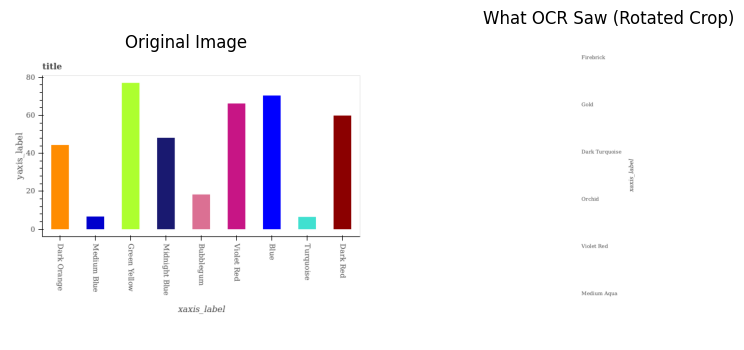

{
    "title": "title",
    "x_axis_labels": [
        "Dark Orange",
        "Medium Blue",
        "Green Yellow",
        "Midnight Blue",
        "Bubblegum",
        "Violet Red",
        "Blue",
        "Turquoise",
        "Dark Red"
    ],
    "values": [
        37.5,
        4.4,
        75.53,
        46.37,
        8.61,
        53.93,
        77.0,
        4.95,
        58.58
    ]
}


In [9]:
def get_graph_json_final(image_path):
    model.eval()
    
    # --- A. Get VALUES from Model ---
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        # Predict 0-1 and scale to 0-100
        preds = model(input_tensor).squeeze().cpu().numpy() * 100.0
    
    # --- B. Get TEXT from OCR ---
    cv_img = cv2.imread(image_path)
    h, w, _ = cv_img.shape
    
    # 1. Title
    title_res = reader.readtext(cv_img[0:int(h*0.15), :])
    title = title_res[0][1] if title_res else "Untitled"
    
    # 2. X-Axis Labels
    label_area = cv_img[int(h*0.70):h, :] 
    label_rot = cv2.rotate(label_area, cv2.ROTATE_90_COUNTERCLOCKWISE)
    label_res = reader.readtext(label_rot)
    
    x_labels = [res[1] for res in label_res if len(res[1]) > 1]
    x_labels = x_labels[::-1]

    # --- C. Intelligent Matching (The Fix) ---
    # 1. Determine Dynamic Threshold (e.g., 5% of the max value)
    max_val = np.max(preds)
    noise_threshold = max_val * 0.05 
    
    # 2. Filter out "Ghost Bars"
    valid_preds = [v for v in preds if v > noise_threshold]
    
    # 3. Match Counts
    # If OCR and Model agree on count (after filtering), perfect.
    # If they disagree, trust the one that found MORE items (safety net),
    # but only if those items are significant.
    count = max(len(x_labels), len(valid_preds))
    count = min(count, 10) 
    
    final_values = [round(float(v), 2) for v in preds[:count]]
    
    # Pad labels ONLY if legitimate bars are missing names
    while len(x_labels) < len(final_values):
        x_labels.append(f"Unknown_Label_{len(x_labels)+1}")

    return {
        "title": title,
        "x_axis_labels": x_labels,
        "values": final_values
    }

# Run Test
test_img_path = f"{vbar_dir}/{train_idx[1]}.png"

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(Image.open(test_img_path))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(debug_img)
plt.title("What OCR Saw (Rotated Crop)")
plt.axis('off')
plt.show()
print(json.dumps(get_graph_json_final(test_img_path), indent=4))

## Training on real dataset for classifiers

In [10]:
import os
import json
import shutil

# Base directory as seen in your screenshot
base_dir = '../FigureQA_Dataset'

# Explicit Train and Validation directories
train_dir = os.path.join(base_dir, 'train1')
val_dir = os.path.join(base_dir, 'validation1')

train_annots = os.path.join(train_dir, 'annotations.json')
val_annots = os.path.join(val_dir, 'annotations.json')

train_images_dir = os.path.join(train_dir, 'png')
val_images_dir = os.path.join(val_dir, 'png')
print("Starting")

Starting


In [11]:
output_dir = './classifier_data'

def prepare_folders(source_images_dir, annotations_file, target_base_dir):
    with open(annotations_file, 'r') as f:
        annotations = json.load(f)

    for item in annotations:
        img_idx = item['image_index']
        graph_type = item['type']
        
        # Create folder for each type inside train/val
        type_dir = os.path.join(target_base_dir, graph_type)
        os.makedirs(type_dir, exist_ok=True)
        
        # Copy image
        src = os.path.join(source_images_dir, f"{img_idx}.png")
        dst = os.path.join(type_dir, f"{img_idx}.png")
        if os.path.exists(src):
            shutil.copy(src, dst)

    print(f"Data organized into {target_base_dir}")

# Run for both Train and Validation sets
prepare_folders(train_images_dir, train_annots, os.path.join(output_dir, 'train'))
prepare_folders(val_images_dir, val_annots, os.path.join(output_dir, 'val'))

Data organized into ./classifier_data/train
Data organized into ./classifier_data/val


In [12]:
from torchvision import datasets, models, transforms
import torch
import torch.nn as nn

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load directly from the specific train and val folders
train_dataset = datasets.ImageFolder(os.path.join(output_dir, 'train'), transform=data_transforms)
val_dataset = datasets.ImageFolder(os.path.join(output_dir, 'val'), transform=data_transforms)

train_size = len(train_dataset)
val_size = len(val_dataset)
print(f"Training images: {train_size}, Validation images: {val_size}")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize Pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

print("Classification model ready for training.")

Training images: 100000, Validation images: 20000
Classification model ready for training.


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
from torchvision import datasets, models, transforms

# 1. Setup hardware acceleration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# ==========================================
# 2. EXPLICITLY LOAD CLASSIFIER DATA
# ==========================================
output_dir = './classifier_data'
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load data specifically from the train/val folders
train_dataset = datasets.ImageFolder(os.path.join(output_dir, 'train'), transform=data_transforms)
val_dataset = datasets.ImageFolder(os.path.join(output_dir, 'val'), transform=data_transforms)

train_size = len(train_dataset)
val_size = len(val_dataset)

# Note: Renamed to 'class_train_loader' to avoid conflicts with the regression step!
class_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
class_val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# ==========================================
# 3. SETUP MODEL & LOSS
# ==========================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
num_epochs = 5 
print(f"Training Classification Model on {device} with {train_size} images...")


for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    running_corrects = 0

    # Ensure we use the freshly loaded classification data
    for i, (inputs, labels) in enumerate(class_train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
        if (i + 1) % 500 == 0:
            print(f"   Epoch {epoch+1} | Processed {i+1}/{len(class_train_loader)} batches... Loss: {loss.item():.4f}")

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.float() / train_size

    # --- VALIDATION PHASE ---
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in class_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    
    val_acc = val_corrects.float() / val_size
    
    duration = time.time() - start_time
    print(f'*** Epoch {epoch+1}/{num_epochs} COMPLETE | '
          f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | '
          f'Val Acc: {val_acc:.4f} | Time: {duration:.0f}s ***\n')

# Save the model weights 
torch.save(model.state_dict(), 'graph_classifier_real.pth')
print("\nSuccess! Model saved as 'graph_classifier_real.pth'")

Training Classification Model on mps with 100000 images...
   Epoch 1 | Processed 500/3125 batches... Loss: 0.0221
   Epoch 1 | Processed 1000/3125 batches... Loss: 0.0048
   Epoch 1 | Processed 1500/3125 batches... Loss: 0.0009
   Epoch 1 | Processed 2000/3125 batches... Loss: 0.0010
   Epoch 1 | Processed 2500/3125 batches... Loss: 0.0007
   Epoch 1 | Processed 3000/3125 batches... Loss: 0.0003
*** Epoch 1/5 COMPLETE | Train Loss: 0.0193 Acc: 0.9971 | Val Acc: 1.0000 | Time: 470s ***

   Epoch 2 | Processed 500/3125 batches... Loss: 0.0172
   Epoch 2 | Processed 1000/3125 batches... Loss: 0.0003
   Epoch 2 | Processed 1500/3125 batches... Loss: 0.0001
   Epoch 2 | Processed 2000/3125 batches... Loss: 0.0000
   Epoch 2 | Processed 2500/3125 batches... Loss: 0.0000
   Epoch 2 | Processed 3000/3125 batches... Loss: 0.0020
*** Epoch 2/5 COMPLETE | Train Loss: 0.0016 Acc: 0.9996 | Val Acc: 1.0000 | Time: 472s ***

   Epoch 3 | Processed 500/3125 batches... Loss: 0.0001
   Epoch 3 | Proces

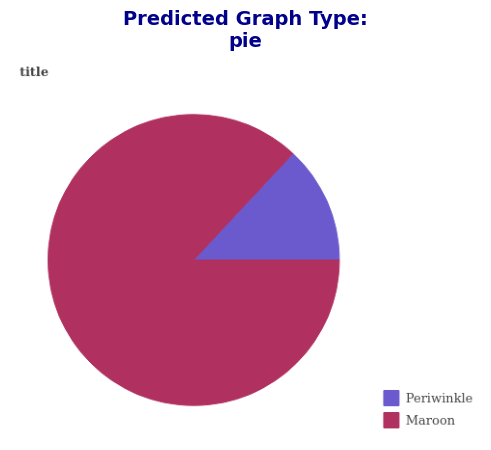

--- Classification Result ---
File: 13423.png
Detected Type: pie



'pie'

In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

# 1. Setup hardware acceleration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# 2. Define the exact class names your model learned
# (PyTorch ImageFolder sorts folders alphabetically)
class_names = ['dot_line', 'hbar_categorical', 'line', 'pie', 'vbar_categorical']

# 3. Re-initialize the model architecture
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

# Load your newly trained weights!
model.load_state_dict(torch.load('graph_classifier_real.pth', map_location=device))
model = model.to(device)
model.eval() # Important: Set to evaluation mode (turns off training mechanics)

# 4. Define the exact same image transformations used in training
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 5. Create the universal prediction function
def classify_graph(image_path):
    # Open image and convert to RGB (just in case it has an alpha channel)
    img = Image.open(image_path).convert('RGB')
    
    # Apply transforms and add a batch dimension so it matches training shape
    img_tensor = data_transforms(img).unsqueeze(0).to(device)
    
    # Run the model
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_class = class_names[preds[0].item()]
    
    # Display the result visually
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.title(f"Predicted Graph Type:\n{predicted_class}", fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()
    
    print(f"--- Classification Result ---")
    print(f"File: {os.path.basename(image_path)}")
    print(f"Detected Type: {predicted_class}\n")
    
    return predicted_class

# ==========================================
# 6. TEST IT ON AN UNSEEN REAL DATASET IMAGE
# ==========================================
test_dir = '../FigureQA_Dataset/no_annot_test1/png'

# Pick a random image from the real test set
all_test_images = [f for f in os.listdir(test_dir) if f.endswith('.png')]
random_test_image = os.path.join(test_dir, random.choice(all_test_images))

# Run your new tool!
detected_type = classify_graph(random_test_image)
detected_type

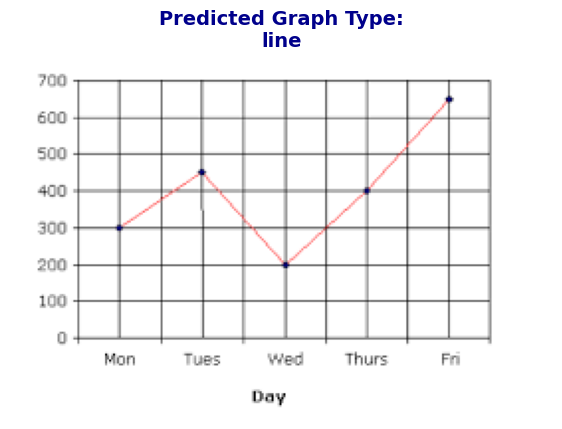

--- Classification Result ---
File: images.png
Detected Type: line



'line'

In [4]:
classify_graph("./Real_Test_Graph/images.png")